In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --- Physical Constants ---
Sixth = 1 / 6
G = 6.6743e-11
c = 299792458
h_Planck = 6.62607e-34
hbar = h_Planck / (2 * np.pi)
k_Boltzmann = 1.380649e-23
eV = 1.602176634e-19
AU = 149597870700
Radian = 180 / np.pi  # Degrees
Degree = np.pi / 180
Arcsec = Degree / 3600
pc = AU / Arcsec
Mpc = pc * 1e6
H_100 = 100e3 / Mpc

GM_Sun = 1.32712440041279419e20
Year = 2*np.pi*np.sqrt(AU*AU*AU/GM_Sun)
Gyr = Year*1e9

# --- Cosmological Parameters ---
N_eff = 3.044  # effective neutrino number
Sum_mnu = 0.06 * eV / (c * c)
R_nu_gamma = N_eff * 7/8 * (4/11)**(4/3)
f_nu = R_nu_gamma / (1 + R_nu_gamma)

T_CMB_firas = 2.72548  # K
rho_crit_100 = 3 * H_100**2 / (8 * np.pi * G)

T_d_ref_CMB = 2892.7189265390 # Reference value for the temperature of the CMB at drag epoch, in K.
T_d_ref = np.array([0.02250, 0.1450, 0.01]) # Reference values for the temperature at drag computation.
T_d_gradient = np.array([5926.7982685835, 203.2921847528, -2.3736921657]) # Gradient for the temperature at drag computation.
T_d_hessian = np.array([[-189596.6848072170, -4765.7156601812, 108.8993400754], 
                        [-4765.7156601812, -624.6877708911, -5.3358430973],
                        [108.8993400754, -5.3358430973, 17.1094164296]]) # Hessian for the temperature at drag computation.

T_star_ref_CMB = 2970.2490798866 # Reference value for the temperature of the CMB at recombination, in K.
T_star_ref = np.array([0.02250, 0.1450, 0.01]) # Reference values for the temperature at recombination computation.
T_star_gradient = np.array([-3187.3522386402, 194.0022355988, -3.8997457516]) # Gradient for the temperature at recombination computation.
T_star_hessian = np.array([[265184.9625445241, -7854.3444118611, 144.6125754140],
                           [-7854.3444118611, -491.8071934238, -9.3247907229],
                           [144.6125754140, -9.3247907229, 23.4632437267]]) # Hessian for the temperature at recombination computation.

def functions_of_Tcmb(T_CMB):
    rho_gamma = np.pi**2 / 15 * (k_Boltzmann**4) / (hbar**3 * c**5) * T_CMB**4

    # --- Photon and Neutrino Densities ---
    zeta_3 = 1.202056903159594  # ζ(3)
    n_gamma = 16 * np.pi * zeta_3 * ((k_Boltzmann * T_CMB / (h_Planck * c))**3)
    n_nu = 3/11 * n_gamma * (N_eff / 3)**0.68
    rho_nu = n_nu * Sum_mnu
    rho_nu_ur = rho_gamma * R_nu_gamma
    a_nr_sqinv = (rho_nu**2) / (rho_nu_ur**2) - 1
    a_nr_sq = 1 / a_nr_sqinv

    w_nu = rho_nu / rho_crit_100
    #print(f"w_nu = {w_nu:.7e}")
    w_gamma = rho_gamma / rho_crit_100
    w_nu_ur = rho_nu_ur / rho_crit_100
    return w_gamma, w_nu, w_nu_ur, a_nr_sq, rho_gamma, rho_nu, rho_nu_ur

# --- DESI DR2 BAO Data ---
z_DESI = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330])
#Data_DESI = np.array([7.942, 13.588, 21.863, 17.351, 19.455, 21.576, 17.641, 27.601, 14.176, 30.512, 12.817, 38.988, 8.632])
DV_Desi = np.array([7.942, 12.720, 16.050, 19.721, 24.252, 26.055, 31.267]) 
eDV_Desi = np.array([0.075, 0.099, 0.110, 0.091, 0.174, 0.398, 0.256])

def reduced_hubble_factor(z, Omega_bc, Omega_gamma, Omega_nu, Omega_nu_ur, a_nr_sq):
    Omega_Lambda = 1 - Omega_bc - Omega_gamma - Omega_nu
    E = np.sqrt(Omega_bc * (1 + z)**3 + Omega_gamma*(1+z)**4 + Omega_Lambda + Omega_nu_ur * np.sqrt(1+1/((1+z)**2*a_nr_sq)) * (1+z)**4 )
    return E

def integrand(z, Omega_bc, Omega_gamma, Omega_nu, Omega_nu_ur, a_nr_sq, H0):
    E = reduced_hubble_factor(z, Omega_bc, Omega_gamma, Omega_nu, Omega_nu_ur, a_nr_sq)
    return 1 / E

def comoving_distance(Omega_bc, Omega_gamma, Omega_nu, Omega_nu_ur, a_nr_sq, H0, z):
    integral, _ = quad(integrand, 0, z, args=(Omega_bc, Omega_gamma, Omega_nu, Omega_nu_ur, a_nr_sq, H0))
    return c / H0 * integral  # Return in metres.

comoving_distance_vec = np.vectorize(comoving_distance, excluded=['Omega_bc', 'Omega_gamma', 'Omega_nu', 'Omega_nu_ur', 'a_nr_sq', 'H0'])

def model_predictions(z, Omega_bc, Omega_gamma, Omega_nu, Omega_nu_ur, a_nr_sq, H0, r_d, z_0):
    z_cosmo = (z - z_0)/(1 + z_0)
    DM_array = comoving_distance_vec(Omega_bc, Omega_gamma, Omega_nu, Omega_nu_ur, a_nr_sq, H0, z_cosmo)
    DH_array = c / (H0 * reduced_hubble_factor(z_cosmo, Omega_bc, Omega_gamma, Omega_nu, Omega_nu_ur, a_nr_sq))  # DH in Mpc
    DV = np.power((DM_array[0] ** 2) * DH_array[0] * z[0], 1.0 / 3.0)
    interleaved = np.stack([DM_array[1:], DH_array[1:]], axis=1).reshape(-1)
    vec = np.concatenate([np.array([DV]), interleaved]) / r_d
    return vec

In [2]:
# Extract MCMC samples from the LCDM chain
data = np.load("dynesty_results_LCDM_no_h0.npz")
samples_LCDM = data['samples']
weights_LCDM = data['weights']
print(f"Extracted {samples_LCDM.shape} samples from the LCDM chain.")
print(samples_LCDM[6000])

Extracted (9769, 3) samples from the LCDM chain.
[2.26371748e-02 2.96830157e-01 6.85938724e+01]


In [3]:
def rd(w_b, w_bc, z0):
    w_b_tilde = w_b/(1 + z0)**3
    w_bc_tilde = w_bc/(1 + z0)**3
    T_cmb_mod = T_CMB_firas * (1 + z0)
    w_gamma, w_nu, w_nu_ur, a_nr_sq, rho_gamma, rho_nu, rho_nu_ur = functions_of_Tcmb(T_cmb_mod)

    d_drag = np.array([w_b_tilde, w_bc_tilde, z0]) - T_d_ref  # Use the parameters to compute d_drag
    T_drag = T_d_ref_CMB + T_d_gradient @ d_drag + 0.5 * d_drag @ T_d_hessian @ d_drag
    z_drag = T_drag / T_cmb_mod - 1
    a_drag = 1 / (1 + z_drag)

    rho_b = w_b * rho_crit_100
    rho_bc = w_bc * rho_crit_100

    R_b_gamma = rho_b / rho_gamma
    R_bc_gamma = rho_bc / rho_gamma
    R_0 = 3/4 * R_b_gamma  # Multiply by a for other epochs

    a_eq = (1 + R_nu_gamma) / R_bc_gamma
    z_eq = 1 / a_eq - 1
    # --- Ratios ---
    R_eq = R_0 * a_eq
    R_drag = R_0 * a_drag

    # --- Sound Horizon ---
    u = (np.sqrt(1 + R_drag) + np.sqrt(R_drag + R_eq)) / (1 + np.sqrt(R_eq))
    r_d = c / H_100 * 2/3 * np.sqrt(3 / w_bc * a_eq / R_eq) * np.log(u)
    return r_d

print(f"Test for rd: {rd(0.022, 0.14, 0.0)/Mpc:.3f} Mpc")

Test for rd: 148.060 Mpc


In [4]:
r_d_array_LCDM = np.array([rd(sample[0], sample[1]*(sample[2]/100)**2, 0.00) for sample in samples_LCDM])
print(f"Computed r_d for the first sample: {r_d_array_LCDM[6000]/Mpc:.3f} Mpc")

Computed r_d for the first sample: 147.610 Mpc


In [5]:
import sys

def model_predictions_DV_rd(z, Omega_bc, Omega_gamma, Omega_nu, Omega_nu_ur, a_nr_sq, H0, r_d, z_0):
    z_cosmo = (z - z_0)/(1 + z_0)
    DM_array = comoving_distance_vec(Omega_bc, Omega_gamma, Omega_nu, Omega_nu_ur, a_nr_sq, H0, z_cosmo)
    DH_array = c / (H0 * reduced_hubble_factor(z_cosmo, Omega_bc, Omega_gamma, Omega_nu, Omega_nu_ur, a_nr_sq))
    DV = np.power((DM_array ** 2) * DH_array * z, 1.0 / 3.0)
    #interleaved = np.stack([DM_array[:], DH_array[1:]], axis=1).reshape(-1)
    return DV/r_d

z = np.linspace(0.1, 2.5, 100)

def model_predictions_DV_rd_MCMC_step(z, r_d, w_b, Omega_bc, H0, z_0):
    DV_rd_MCMC = np.zeros((len(w_b), len(z)))
    for i in range(len(w_b)):
        # Every 1000 steps, print the progress
        if i % 1000 == 0:
            print(f"Processing sample {i}/{len(w_b)}")
        T_cmb_mod = T_CMB_firas * (1 + z_0[i])
        w_gamma, w_nu, w_nu_ur, a_nr_sq, _, _, _ = functions_of_Tcmb(T_cmb_mod)
        Omega_gamma = w_gamma * (H0[i]/100)**2
        Omega_nu = w_nu * (H0[i]/100)**2
        Omega_nu_ur = w_nu_ur * (H0[i]/100)**2
        DV_rd_MCMC[i,:] = model_predictions_DV_rd(z, Omega_bc[i], Omega_gamma, Omega_nu, Omega_nu_ur, a_nr_sq, H0[i]/100*H_100, r_d[i], z_0[i])
    return DV_rd_MCMC

In [6]:
z0_LCDM = np.zeros(len(samples_LCDM))

DV_rd_MCMC_LCDM = model_predictions_DV_rd_MCMC_step(z, r_d_array_LCDM, samples_LCDM[:,0], samples_LCDM[:,1], samples_LCDM[:,2], z0_LCDM)

Processing sample 0/9769
Processing sample 1000/9769
Processing sample 2000/9769
Processing sample 3000/9769
Processing sample 4000/9769
Processing sample 5000/9769
Processing sample 6000/9769
Processing sample 7000/9769
Processing sample 8000/9769
Processing sample 9000/9769


In [12]:
DV_rd_mean_MCMC_LCDM = np.average(DV_rd_MCMC_LCDM, weights=weights_LCDM, axis=0)
DV_rd_std_MCMC_LCDM = np.average((DV_rd_MCMC_LCDM - DV_rd_mean_MCMC_LCDM)**2, weights=weights_LCDM, axis=0)
DV_rd_std_MCMC_LCDM = np.sqrt(DV_rd_std_MCMC_LCDM)
i = 17; print(f"DV/rd at z={z[i]:.2f}: {DV_rd_mean_MCMC_LCDM[i]:.3f} ± {DV_rd_std_MCMC_LCDM[i]:.3f}")

DV/rd at z=0.51: 12.771 ± 0.037


In [14]:
data = np.load("dynesty_results_z0_no_h0.npz")
samples_z0_free = data['samples']
weights_z0_free = data['weights']
r_d_z0_free = np.array([rd(sample[0], sample[1]*(sample[2]/100)**2, sample[3]) for sample in samples_z0_free])

In [15]:
DV_rd_MCMC_z0_free = model_predictions_DV_rd_MCMC_step(z, r_d_z0_free, samples_z0_free[:,0], samples_z0_free[:,1], samples_z0_free[:,2], samples_z0_free[:,3])

Processing sample 0/10776
Processing sample 1000/10776
Processing sample 2000/10776
Processing sample 3000/10776
Processing sample 4000/10776
Processing sample 5000/10776
Processing sample 6000/10776
Processing sample 7000/10776
Processing sample 8000/10776
Processing sample 9000/10776
Processing sample 10000/10776


In [ ]:
DV_rd_mean_z0_free = np.average(DV_rd_MCMC_z0_free, weights=weights_z0_free, axis=0)

# Upper 1-sigma limit


In [16]:
def weighted_percentile(data, weights, percentiles, axis=0):
    """
    Compute weighted percentiles along specified axis.
    
    Parameters:
    -----------
    data : array
        Data array
    weights : array
        Weights for each sample
    percentiles : array-like
        Percentiles to compute (0-100)
    axis : int
        Axis along which to compute percentiles
        
    Returns:
    --------
    Array of percentile values
    """
    if axis == 0:
        # For each column, compute weighted percentile
        result = np.zeros((len(percentiles), data.shape[1]))
        for i in range(data.shape[1]):
            sorted_indices = np.argsort(data[:, i])
            sorted_data = data[sorted_indices, i]
            sorted_weights = weights[sorted_indices]
            
            # Cumulative sum of weights
            cumsum = np.cumsum(sorted_weights)
            cumsum = cumsum / cumsum[-1]  # Normalize to [0, 1]
            
            # Interpolate to find percentile values
            for j, p in enumerate(percentiles):
                result[j, i] = np.interp(p / 100.0, cumsum, sorted_data)
        return result
    else:
        raise NotImplementedError("Only axis=0 is implemented")

# Usage for 1 and 2 sigma:
percentiles_1sigma = weighted_percentile(DV_rd_MCMC_z0_free, weights_z0_free, [15.87, 84.13], axis=0)
lower_1sigma_z0_free = percentiles_1sigma[0]
upper_1sigma_z0_free = percentiles_1sigma[1]

percentiles_2sigma = weighted_percentile(DV_rd_MCMC_z0_free, weights_z0_free, [2.275, 97.725], axis=0)
lower_2sigma_z0_free = percentiles_2sigma[0]
upper_2sigma_z0_free = percentiles_2sigma[1]

DV_rd_mean_z0_free = np.average(DV_rd_MCMC_z0_free, weights=weights_z0_free, axis=0)

In [17]:
alpha_iso_mean_z0_free = DV_rd_mean_z0_free / DV_rd_mean_MCMC_LCDM
alpha_iso_lower_1sigma_z0_free = lower_1sigma_z0_free / DV_rd_mean_MCMC_LCDM
alpha_iso_upper_1sigma_z0_free = upper_1sigma_z0_free / DV_rd_mean_MCMC_LCDM
alpha_iso_lower_2sigma_z0_free = lower_2sigma_z0_free / DV_rd_mean_MCMC_LCDM
alpha_iso_upper_2sigma_z0_free = upper_2sigma_z0_free / DV_rd_mean_MCMC_LCDM

In [20]:
# Interpolate LCDM predictions at DESI redshifts
DV_rd_LCDM_at_DESI = np.interp(z_DESI, z, DV_rd_mean_MCMC_LCDM)

alpha_iso_DESI = DV_Desi / DV_rd_LCDM_at_DESI
ealpha_iso_DESI = eDV_Desi / DV_rd_LCDM_at_DESI

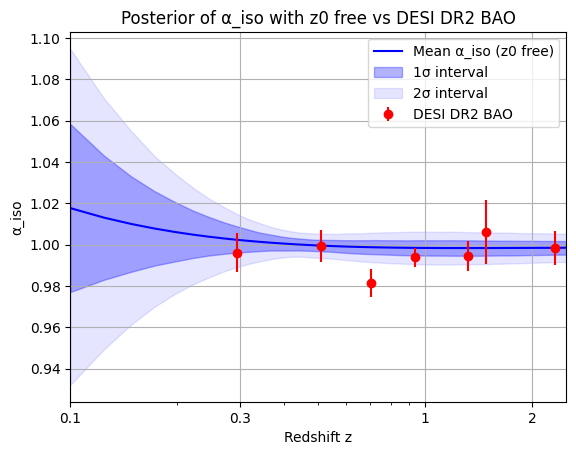

In [25]:
plt.plot(z, alpha_iso_mean_z0_free, label='Mean α_iso (z0 free)', color='blue')
plt.fill_between(z, alpha_iso_lower_1sigma_z0_free, alpha_iso_upper_1sigma_z0_free, color='blue', alpha=0.3, label='1σ interval')
plt.fill_between(z, alpha_iso_lower_2sigma_z0_free, alpha_iso_upper_2sigma_z0_free, color='blue', alpha=0.1, label='2σ interval')
plt.errorbar(z_DESI, alpha_iso_DESI, yerr=ealpha_iso_DESI, fmt='o', color='red', label='DESI DR2 BAO')
plt.xlabel('Redshift z')
plt.ylabel('α_iso')
plt.xscale('log')
plt.xlim(0.1, 2.5)
plt.xticks([0.1, 0.3, 1, 2], ['0.1', '0.3', '1', '2'])
plt.title('Posterior of α_iso with z0 free vs DESI DR2 BAO')
plt.legend()
plt.grid()
plt.savefig("alpha_iso_posterior_z0_free_vs_DESI.pdf")

In [ ]:
data = np.load("dynesty_results_z0_no_h0_0.005.npz")
samples_z0_5ppt = data['samples']
weights_z0_5ppt = data['weights']
z0_5ppt = 0.005
r_d_z0_5ppt = np.array([rd(sample[0], sample[1]*(sample[2]/100)**2, z0_5ppt) for sample in samples_z0_5ppt])

In [ ]:
z0_5ppt_array = np.full(len(samples_z0_5ppt), z0_5ppt)

DV_rd_MCMC_z0_5ppt = model_predictions_DV_rd_MCMC_step(z, r_d_z0_5ppt, samples_z0_5ppt[:,0], samples_z0_5ppt[:,1], samples_z0_5ppt[:,2], z0_5ppt_array)

Processing sample 0/9752
Processing sample 1000/9752
Processing sample 2000/9752
Processing sample 3000/9752
Processing sample 4000/9752
Processing sample 5000/9752
Processing sample 6000/9752
Processing sample 7000/9752
Processing sample 8000/9752
Processing sample 9000/9752


In [30]:
DV_rd_mean_z0_5ppt = np.average(DV_rd_MCMC_z0_5ppt, weights=weights_z0_5ppt, axis=0)
alpha_iso_mean_z0_5ppt = DV_rd_mean_z0_5ppt/DV_rd_mean_MCMC_LCDM

In [31]:
data = np.load("dynesty_results_z0_no_h0_0.0084.npz")
samples_z0_HBK20 = data['samples']
weights_z0_HBK20 = data['weights']
z0_HBK20 = 0.0084
r_d_z0_HBK20 = np.array([rd(sample[0], sample[1]*(sample[2]/100)**2, z0_HBK20) for sample in samples_z0_HBK20])

In [32]:
z0_HBK20_array = np.full(len(samples_z0_HBK20), z0_HBK20)

DV_rd_MCMC_z0_HBK20 = model_predictions_DV_rd_MCMC_step(z, r_d_z0_HBK20, samples_z0_HBK20[:,0], samples_z0_HBK20[:,1], samples_z0_HBK20[:,2], z0_HBK20_array)

Processing sample 0/9617
Processing sample 1000/9617
Processing sample 2000/9617
Processing sample 3000/9617
Processing sample 4000/9617
Processing sample 5000/9617
Processing sample 6000/9617
Processing sample 7000/9617
Processing sample 8000/9617
Processing sample 9000/9617


In [33]:
DV_rd_mean_z0_HBK20 = np.average(DV_rd_MCMC_z0_HBK20, weights=weights_z0_HBK20, axis=0)
alpha_iso_mean_z0_HBK20 = DV_rd_mean_z0_HBK20/DV_rd_mean_MCMC_LCDM

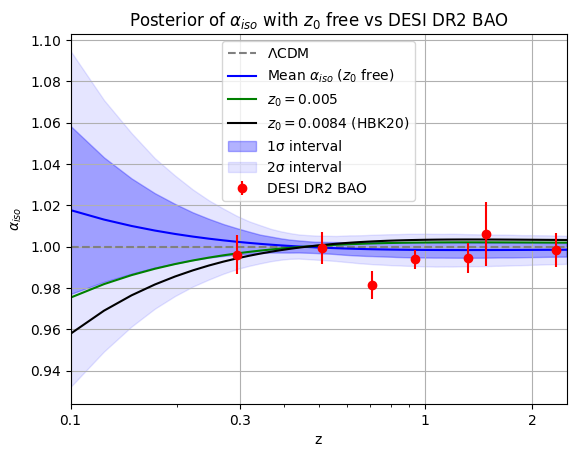

In [38]:
plt.axhline(y=1, color='gray', linestyle='--', label='$\\Lambda$CDM')
plt.plot(z, alpha_iso_mean_z0_free, label='Mean $\\alpha_{iso}$ ($z_0$ free)', color='blue')
plt.plot(z, alpha_iso_mean_z0_5ppt, label='$z_0=0.005$', color='green')
plt.plot(z, alpha_iso_mean_z0_HBK20, label='$z_0=0.0084$ (HBK20)', color='black')
plt.fill_between(z, alpha_iso_lower_1sigma_z0_free, alpha_iso_upper_1sigma_z0_free, color='blue', alpha=0.3, label='1σ interval')
plt.fill_between(z, alpha_iso_lower_2sigma_z0_free, alpha_iso_upper_2sigma_z0_free, color='blue', alpha=0.1, label='2σ interval')
plt.errorbar(z_DESI, alpha_iso_DESI, yerr=ealpha_iso_DESI, fmt='o', color='red', label='DESI DR2 BAO')
plt.xlabel('z')
plt.ylabel('$\\alpha_{iso}$')
plt.xscale('log')
plt.xlim(0.1, 2.5)
plt.xticks([0.1, 0.3, 1, 2], ['0.1', '0.3', '1', '2'])
plt.title('Posterior of $\\alpha_{iso}$ with $z_0$ free vs DESI DR2 BAO')
plt.legend(loc='upper center')
plt.grid()
plt.savefig("alpha_iso_posterior_z0_free_vs_DESI_all.pdf")